In [1]:
import os
import numpy as np
import tensorflow as tf
from PIL import Image
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Set memory growth to avoid GPU memory issues
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

2025-07-28 13:07:01.979292: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753722421.995554  855606 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753722422.000638  855606 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753722422.012439  855606 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753722422.012452  855606 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753722422.012454  855606 computation_placer.cc:177] computation placer alr

In [2]:
images_dir = '/hpcstor6/scratch01/a/a.kanamarlapudi001/datasets/test_balanced/images'
masks_dir = '/hpcstor6/scratch01/a/a.kanamarlapudi001/datasets/test_balanced/masks'

basenames = [os.path.splitext(f)[0] for f in os.listdir(images_dir) if f.endswith('.npz')]

train_basenames, temp_basenames = train_test_split(basenames, test_size=0.2, random_state=42)
val_basenames, test_basenames = train_test_split(temp_basenames, test_size=0.5, random_state=42)

print(f'Train: {len(train_basenames)}, Validation: {len(val_basenames)}, Test: {len(test_basenames)}')

Train: 9284, Validation: 1161, Test: 1161


In [3]:
IMG_SIZE = (256, 256)

def load_and_preprocess_image(basename):
    """Load and preprocess a single image"""
    basename_str = basename.numpy().decode('utf-8')
    
    # Load image
    img_path = os.path.join(images_dir, basename_str + '.npz')
    arr = np.load(img_path)
    if isinstance(arr, np.lib.npyio.NpzFile):
        img = arr[arr.files[0]]
    else:
        img = arr
    
    # Ensure 3D array (height, width, channels)
    if img.ndim == 2:
        img = img[..., np.newaxis]
    
    # Resize and normalize
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    
    return img

def load_and_preprocess_mask(basename):
    """Load and preprocess a single mask"""
    basename_str = basename.numpy().decode('utf-8')
    
    # Load mask
    mask_path = os.path.join(masks_dir, basename_str + '.png')
    mask = np.array(Image.open(mask_path))
    
    # Ensure 3D array
    if mask.ndim == 2:
        mask = mask[..., np.newaxis]
    
    # Resize and normalize
    mask = tf.image.resize(mask, IMG_SIZE, method='nearest')
    mask = tf.cast(mask, tf.float32) / 255.0
    
    return mask

def create_dataset(basenames, batch_size=8, shuffle=True):
    """Create a TensorFlow dataset with proper shape handling"""
    dataset = tf.data.Dataset.from_tensor_slices(basenames)
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=min(len(basenames), 1000))
    
    # Load images and masks separately to avoid shape issues
    dataset = dataset.map(
        lambda x: (tf.py_function(load_and_preprocess_image, [x], tf.float32),
                   tf.py_function(load_and_preprocess_mask, [x], tf.float32)),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    
    # Set output shapes explicitly
    dataset = dataset.map(
        lambda img, mask: (tf.ensure_shape(img, (IMG_SIZE[0], IMG_SIZE[1], 1)),
                           tf.ensure_shape(mask, (IMG_SIZE[0], IMG_SIZE[1], 1))),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

# Create datasets with smaller batch size to avoid memory issues
train_dataset = create_dataset(train_basenames, batch_size=8, shuffle=True)
val_dataset = create_dataset(val_basenames, batch_size=8, shuffle=False)
test_dataset = create_dataset(test_basenames, batch_size=8, shuffle=False)

print("Datasets created successfully!")

Datasets created successfully!


I0000 00:00:1753722433.514408  855606 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 887 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:07:00.0, compute capability: 8.0


In [4]:
# Test the data loading
print("Testing data loading...")
for images, masks in train_dataset.take(1):
    print(f"Image shape: {images.shape}")
    print(f"Mask shape: {masks.shape}")
    print(f"Image dtype: {images.dtype}")
    print(f"Mask dtype: {masks.dtype}")
    print(f"Image range: [{tf.reduce_min(images):.3f}, {tf.reduce_max(images):.3f}]")
    print(f"Mask range: [{tf.reduce_min(masks):.3f}, {tf.reduce_max(masks):.3f}]")
    break
print("Data loading test completed!")

Testing data loading...
Image shape: (8, 256, 256, 1)
Mask shape: (8, 256, 256, 1)
Image dtype: <dtype: 'float32'>
Mask dtype: <dtype: 'float32'>
Image range: [0.000, 15.912]
Mask range: [0.000, 1.000]
Data loading test completed!


In [5]:
def unet_model(input_size=(256, 256, 1)):
    inputs = tf.keras.layers.Input(input_size)
    
    # Encoder
    c1 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
    c1 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', padding='same')(c1)
    p1 = tf.keras.layers.MaxPooling2D((2, 2))(c1)

    c2 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same')(p1)
    c2 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c2)
    p2 = tf.keras.layers.MaxPooling2D((2, 2))(c2)

    c3 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(p2)
    c3 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c3)
    p3 = tf.keras.layers.MaxPooling2D((2, 2))(c3)

    c4 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p3)
    c4 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c4)
    p4 = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(c4)

    # Bottleneck
    c5 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p4)
    c5 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c5)

    # Decoder
    u6 = tf.keras.layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = tf.keras.layers.concatenate([u6, c4])
    c6 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u6)
    c6 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c6)

    u7 = tf.keras.layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = tf.keras.layers.concatenate([u7, c3])
    c7 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u7)
    c7 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c7)

    u8 = tf.keras.layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = tf.keras.layers.concatenate([u8, c2])
    c8 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same')(u8)
    c8 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c8)

    u9 = tf.keras.layers.Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = tf.keras.layers.concatenate([u9, c1])
    c9 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', padding='same')(u9)
    c9 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', padding='same')(c9)

    outputs = tf.keras.layers.Conv2D(1, (1, 1), activation='sigmoid')(c9)

    model = tf.keras.Model(inputs=[inputs], outputs=[outputs])
    return model

model = unet_model()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        160 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      2,320 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │    295,168 │ max_pooling2d_3[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │    590,080 │ conv2d_8[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 32, 32,    │    131,200 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_transpose

 Total params: 1,940,817 (7.40 MB)

 Trainable params: 1,940,817 (7.40 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Add callbacks for better training
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

callbacks = [
    ModelCheckpoint('best_unet_model.h5', monitor='val_loss', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

EPOCHS = 20
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20


/home/a.kanamarlapudi001/miniconda3/envs/tf_gpu_env/lib/python3.10/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 256, 256, 1))
  warnings.warn(msg)
I0000 00:00:1753722469.349068  855803 service.cc:152] XLA service 0x7faba8003650 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1753722469.349101  855803 service.cc:160]   StreamExecutor device (0): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
2025-07-28 13:07:49.555367: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1753722470.328345  855803 cuda_dnn.cc:529] Loaded cuDNN version 90300
Could not load symbol cuFuncGetName. Error: /usr/lib/x86_64-linux-gnu/libcuda.so.1: undefined symbol: cuFuncGetName
2025-07-28 13:07:51.768134

   4/1161 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.3585 - loss: 0.7131   

I0000 00:00:1753722476.843263  855803 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2025-07-28 13:07:56.846931: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:382] Garbage collection: deallocate free memory regions (i.e., allocations) so that we can re-allocate a larger region to avoid OOM due to memory fragmentation. If you see this message frequently, you are running near the threshold of the available device memory and re-allocation may incur great performance overhead. You may try smaller batch sizes to observe the performance impact. Set TF_ENABLE_GPU_GARBAGE_COLLECTION=false if you'd like to disable this feature.


1161/1161 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9832 - loss: 0.0694
Epoch 1: val_loss improved from inf to 0.03193, saving model to best_unet_model.h5


...

1161/1161 ━━━━━━━━━━━━━━━━━━━━ 83s 54ms/step - accuracy: 0.9931 - loss: 0.0239 - val_accuracy: 0.9931 - val_loss: 0.0224 - learning_rate: 0.0010
Epoch 10/20
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9931 - loss: 0.0231
Epoch 10: val_loss did not improve from 0.02237
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 81s 53ms/step - accuracy: 0.9931 - loss: 0.0231 - val_accuracy: 0.9932 - val_loss: 0.0230 - learning_rate: 0.0010
Epoch 11/20
1160/1161 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9932 - loss: 0.0227
Epoch 11: val_loss improved from 0.02237 to 0.02207, saving model to best_unet_model.h5


1161/1161 ━━━━━━━━━━━━━━━━━━━━ 62s 53ms/step - accuracy: 0.9932 - loss: 0.0227 - val_accuracy: 0.9932 - val_loss: 0.0221 - learning_rate: 0.0010
Epoch 12/20
1160/1161 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9932 - loss: 0.0224
Epoch 12: val_loss improved from 0.02207 to 0.02187, saving model to best_unet_model.h5


1161/1161 ━━━━━━━━━━━━━━━━━━━━ 82s 53ms/step - accuracy: 0.9932 - loss: 0.0224 - val_accuracy: 0.9932 - val_loss: 0.0219 - learning_rate: 0.0010
Epoch 13/20
1160/1161 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9933 - loss: 0.0220
Epoch 13: val_loss did not improve from 0.02187
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 66s 57ms/step - accuracy: 0.9933 - loss: 0.0220 - val_accuracy: 0.9933 - val_loss: 0.0230 - learning_rate: 0.0010
Epoch 14/20
1160/1161 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9934 - loss: 0.0214
Epoch 14: val_loss did not improve from 0.02187
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 78s 53ms/step - accuracy: 0.9934 - loss: 0.0214 - val_accuracy: 0.9933 - val_loss: 0.0229 - learning_rate: 0.0010
Epoch 15/20
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9934 - loss: 0.0217
Epoch 15: val_loss improved from 0.02187 to 0.02133, saving model to best_unet_model.h5


1161/1161 ━━━━━━━━━━━━━━━━━━━━ 87s 57ms/step - accuracy: 0.9934 - loss: 0.0217 - val_accuracy: 0.9933 - val_loss: 0.0213 - learning_rate: 0.0010
Epoch 16/20
1160/1161 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9935 - loss: 0.0211
Epoch 16: val_loss improved from 0.02133 to 0.02118, saving model to best_unet_model.h5


1161/1161 ━━━━━━━━━━━━━━━━━━━━ 61s 53ms/step - accuracy: 0.9935 - loss: 0.0211 - val_accuracy: 0.9934 - val_loss: 0.0212 - learning_rate: 0.0010
Epoch 17/20
1160/1161 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9936 - loss: 0.0208
Epoch 17: val_loss did not improve from 0.02118
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 82s 53ms/step - accuracy: 0.9936 - loss: 0.0208 - val_accuracy: 0.9922 - val_loss: 0.0244 - learning_rate: 0.0010
Epoch 18/20
1160/1161 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9936 - loss: 0.0205
Epoch 18: val_loss did not improve from 0.02118
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 66s 57ms/step - accuracy: 0.9936 - loss: 0.0205 - val_accuracy: 0.9930 - val_loss: 0.0225 - learning_rate: 0.0010
Epoch 19/20
1160/1161 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9938 - loss: 0.0202
Epoch 19: val_loss did not improve from 0.02118

Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 61s 53ms/step - accuracy: 0.9938 - loss: 0

In [7]:
results = model.evaluate(test_dataset, verbose=1)
print(f'Test Loss: {results[0]:.4f}, Test Accuracy: {results[1]:.4f}')

146/146 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.9933 - loss: 0.0218
Test Loss: 0.0218, Test Accuracy: 0.9934


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


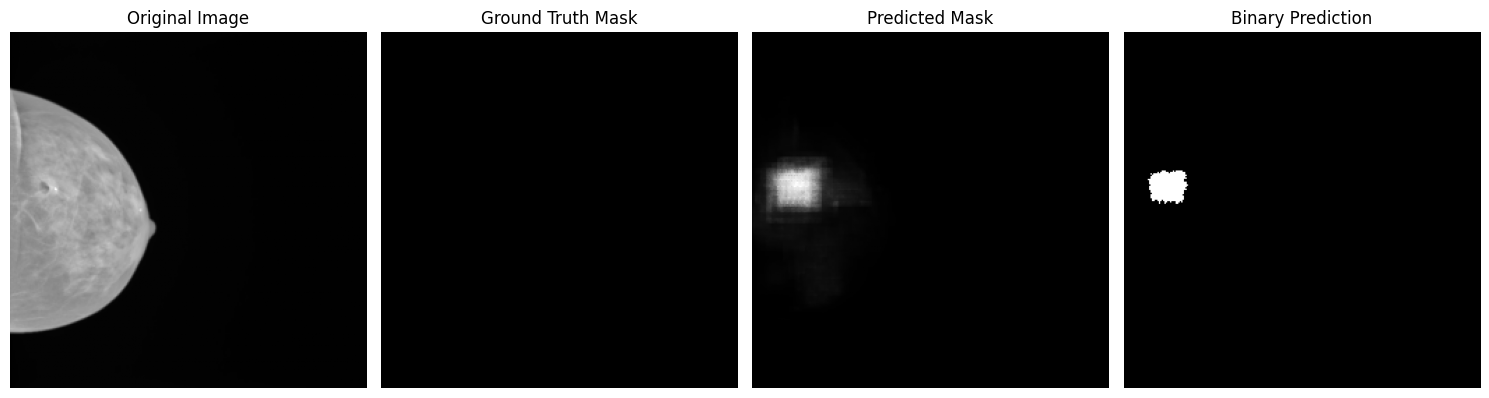

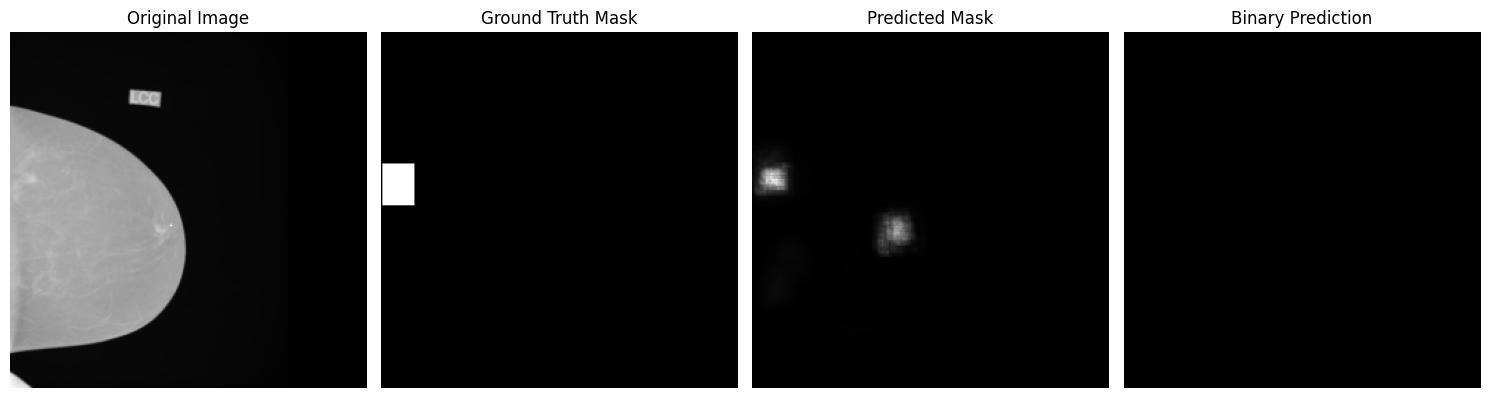

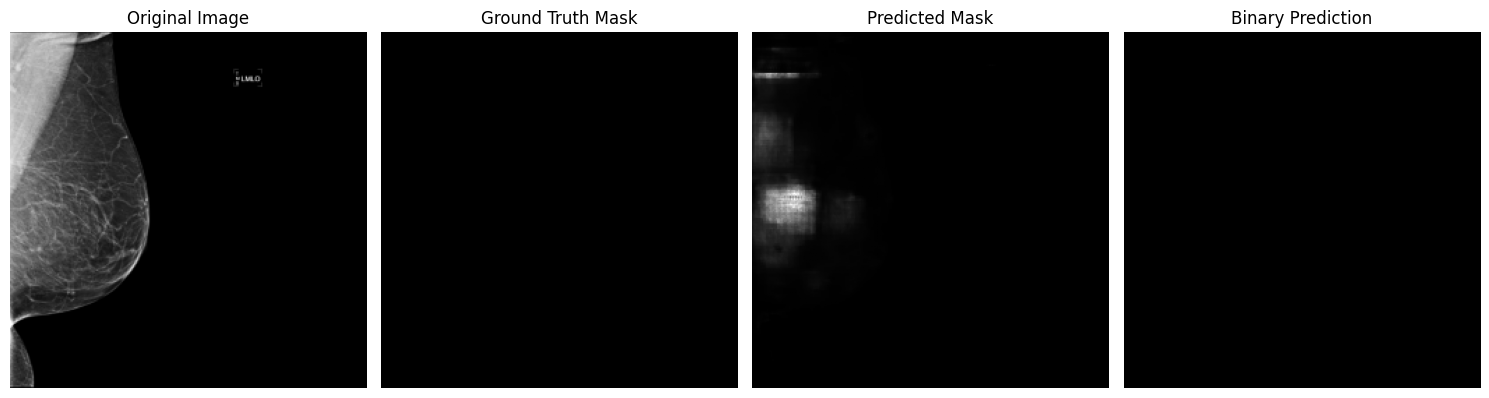

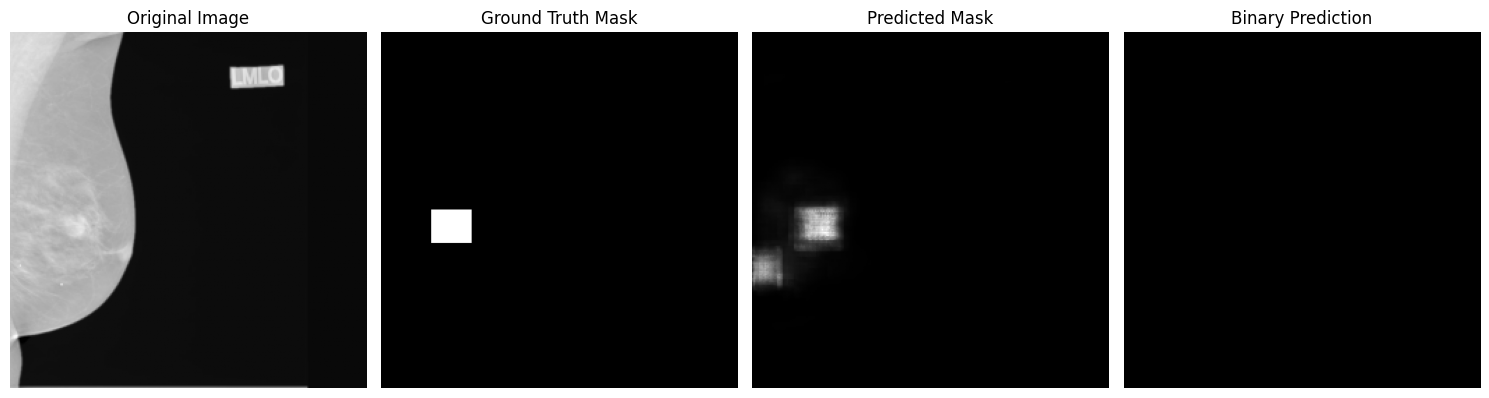

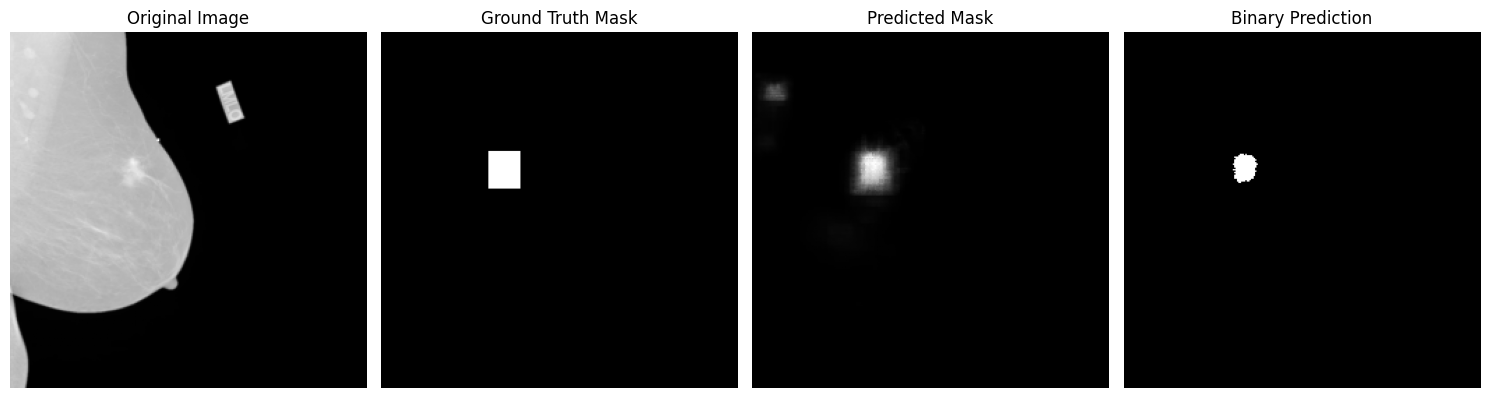

In [11]:
for images, masks in test_dataset.take(1):
    preds = model.predict(images)
    for i in range(5):  # Show 3 examples
        plt.figure(figsize=(15, 5))
        
        plt.subplot(1, 4, 1)
        plt.title('Original Image')
        plt.imshow(tf.squeeze(images[i]), cmap='gray')
        plt.axis('off')
        
        plt.subplot(1, 4, 2)
        plt.title('Ground Truth Mask')
        plt.imshow(tf.squeeze(masks[i]), cmap='gray')
        plt.axis('off')
        
        plt.subplot(1, 4, 3)
        plt.title('Predicted Mask')
        plt.imshow(tf.squeeze(preds[i]), cmap='gray')
        plt.axis('off')
        
        plt.subplot(1, 4, 4)
        plt.title('Binary Prediction')
        plt.imshow(tf.squeeze(preds[i]) > 0.5, cmap='gray')
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
    break

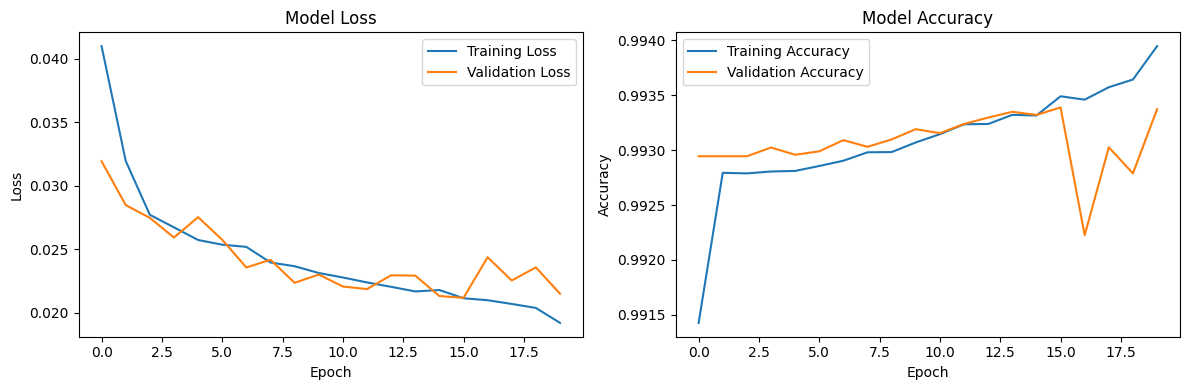

In [9]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()